In [2]:
from astropy.table import Table
from common_functions import wavelet_rebased, plotter, reduce
import os
import pathlib
from pyasassn.client import SkyPatrolClient
import matplotlib.pyplot as plt

/Users/mschochet/anaconda3/envs/asassncnn/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# This notebook is meant to demonstrate how one would make a single object wavelet transform given a specific ASAS-SN ID

In [3]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [4]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [5]:
def pipeline(objid, minimum=False, scaling=False):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    wavelet = wavelet_rebased(savedlc_fin, min=minimum, scaled=scaling, tradeoff=2)
    if (minimum==True):
        plotter(wavelet, True, "yes", "not")
    elif (scaling==True):
        plotter(wavelet, True, "not", "yes")
    else:
        plotter(wavelet, True)
    return(wavelet)

Pulled 1 of 1


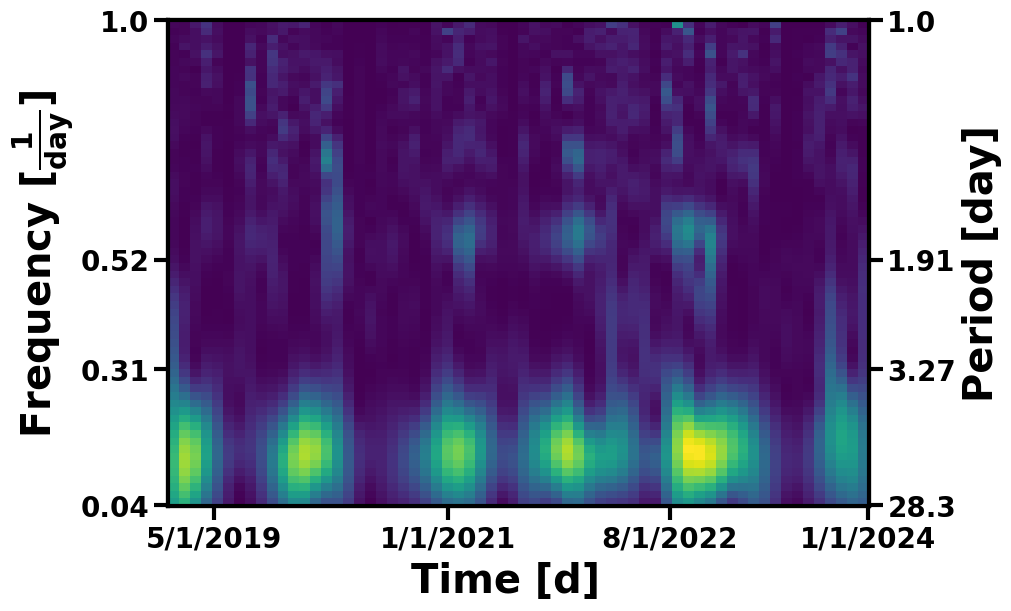

In [6]:
savedlc = pipeline(463856975202)

Pulled 1 of 1


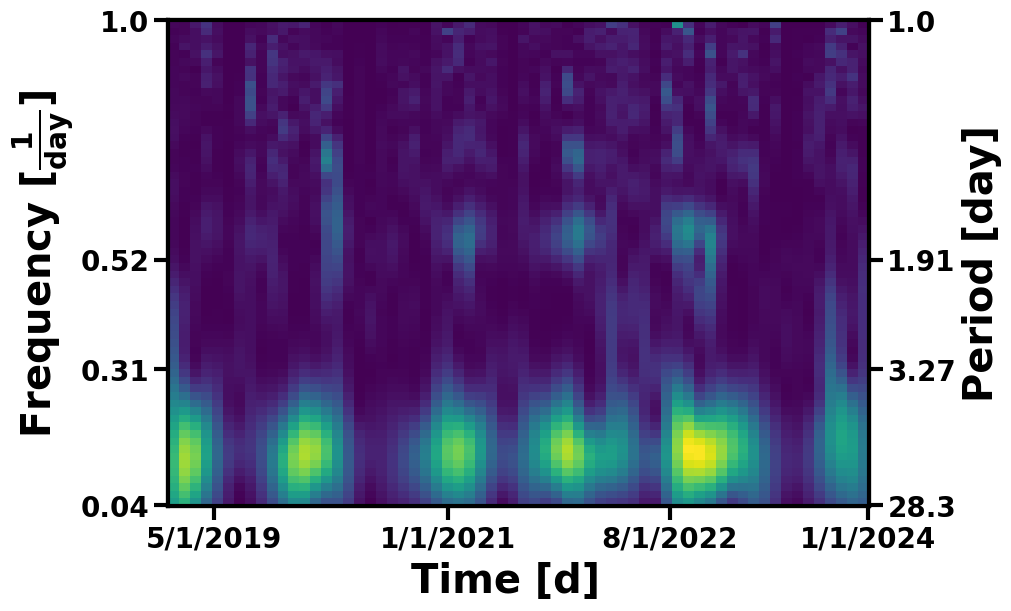

In [7]:
minmasked = pipeline(463856975202, True)

Pulled 1 of 1


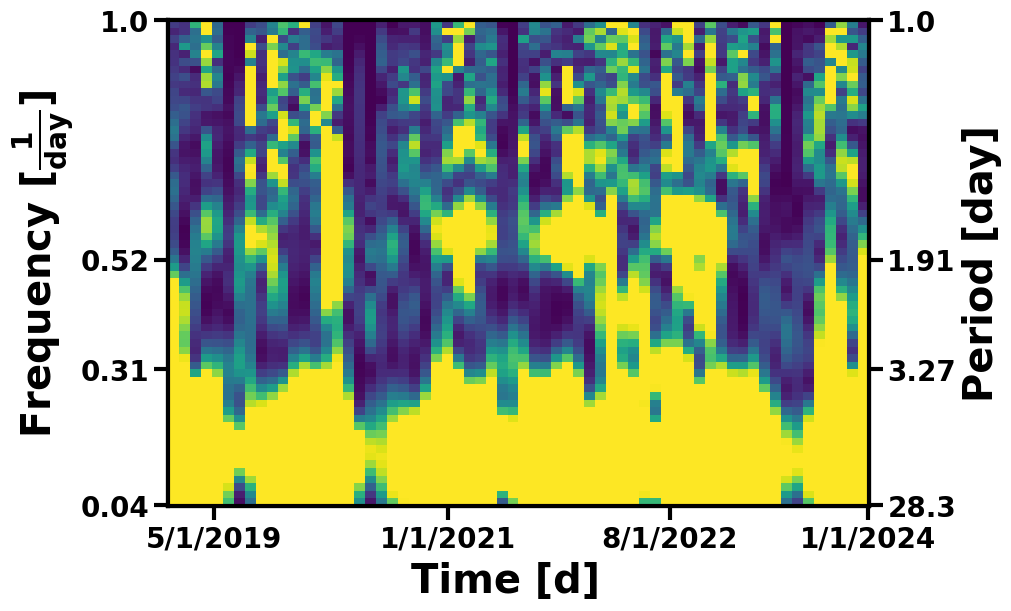

In [8]:
scaled10x = pipeline(463856975202, scaling=True)